# Euclid Q1 hands-on: AGN selection on a color SOM

**AAS workshop:** *Euclid Data in the Cloud - Access, Analysis, and Science Opportunities* (90 min)

Active galactic nuclei (AGN) are accreting supermassive black holes — the engines behind black hole / galaxy co-evolution, cosmic feedback, and a lot of what powers the bright end of every extragalactic survey. The catch: there is no single way to *find* them. Mid-infrared colors (WISE) pick up hot dust, optical/NIR color boxes pick up the blue power-law continuum, Gaia parallaxes pick out unresolved quasars, spectroscopy picks up broad lines, SED fits pick up template mismatches, and so on. These methods overlap, but not 1:1 — each finds AGN the others miss.

Euclid Q1 gives us broadband photometry (VIS + Y, J, H from NISP + ancillary ground-based g, r, i, z) across millions of galaxies — enough to ask a sharper version of the question: **once you place every galaxy on a common manifold defined by its broadband colors, do different AGN selection methods land in the same place, or different ones and how much they overlap?**

## Why a SOM

A [Self-Organizing Map (SOM; Kohonen 1982)](https://en.wikipedia.org/wiki/Self-organizing_map) is an unsupervised neural network that takes high-dimensional data (here, six adjacent galaxy colors per source) and lays it out on a 2D grid so that *nearby cells contain galaxies with similar colors*. The result is a "color atlas" of the survey: each cell represents a galaxy type, and every new source can be projected to its single **best-matching unit (BMU)** — the cell whose color template fits it best. Once the map exists, comparing AGN selection methods becomes a 2D picture: overlay each method's AGN, see where it lights up.

## What's pre-built, and why

Training the SOM on tens of thousands of Q1 galaxies takes a couple of minutes — too long for a 30-minute workshop slot. So we ship the trained SOM weights (`workshop_som.pkl`) and a small (~350 KB) table of EDF-N AGN object IDs + selection flags + redshifts (`workshop_agn_flags_edfn.fits`, derived from Euclid Collaboration: Matamoro Zatarain et al. 2025 — the AGN-candidate catalog is paper-companion and not yet served via IRSA TAP). Everything else — the photometry, the colors, the BMU projection — you'll fetch and compute live against IRSA in Task 1.

## What you'll do (~30 min)

This hands-on focuses on the **cloud-access** half of the workshop title. Three tasks:

1. **Task 1** - Query Euclid's MER photometric catalog **live from IRSA TAP** for the AGN candidates, compute six adjacent colors, and project each candidate onto the pre-trained SOM. The map at the end shows where the *union* of AGN selection methods sits on the color manifold.
2. **Task 2** - Pick one selection method (WISE, Gaia, DESI, ...) and visualize where it sits on the manifold relative to the union. Compare with your neighbor: do different selections pick out the same neighborhood, or different ones?
3. **Task 3** - Pick one AGN candidate and verify it against three independent **live cloud reads** against IRSA: its 1D Q1 SIR spectrum (direct S3 FITS read), its multi-band MER imaging (IBE server-side cutout), and its SPE H$\alpha$ line measurement (live TAP query).

**The cloud point.** Tasks 1 and 3 fetch data live at workshop time from `s3://nasa-irsa-euclid-q1/...` or `https://irsa.ipac.caltech.edu/...`. No downloads happen to disk. Running this on Fornax it's region-local and instant; from a laptop it works too over the public HTTPS/anonymous-S3 endpoints. The same code scales unchanged to the full Q1 release and onward to DR1.

**Scope.** EDF-N AGN candidates from Euclid Collaboration: Matamoro Zatarain et al. (2025), in the redshift window `1.30 < z < 1.80` (H$\alpha$ in the NISP red grism), with photometric gates (per-band S/N > 5, AB in [12, 30], MER 7-band) applied live during Task 1.


## 0. Setup

Load libraries and the two pre-built local artifacts: the trained SOM and the
small flag-only AGN table. No cloud reads yet - those start in Task 1.


In [30]:
# Standard library and third-party imports.
import os
import json
import pickle
import warnings

import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, join
from astropy.utils.metadata import MergeConflictWarning
from astroquery.ipac.irsa import Irsa

# Project helpers (data IO, SOM utilities, plot overlays, spectrum/cutout fetch).
from workshop_utils import (
    AGN_OVERLAY_COLOR, COLOR_NAMES, METHOD_CONTOUR_COLOR, SPE_LINES_TABLE,
    SPECTRA_ASSOC_TABLE, SPECTRA_BUCKET,
    abmag, batched_query, bmu_density, coalesce,
    continuum_normalized_rest_spectrum, fill_nan_nearest,
    get_Q1_mer_cutout, get_Q1_sir_spectra, jitter_bmu, mark_halpha_complex,
    median_map, overlay, overlay_method_excess, project, snr, valid_mag,
)

# AGN selection flags shipped in the flag-only file.
COMMON_FLAGS = [
    'PRF_qso_candidate', 'B24a_qso_candidate',
    'C75_agn_candidate', 'R90_agn_candidate',
    'GDR3_qso_candidate',
    'JH_IeY_qso_candidate', 'IeH_gz_qso_candidate',
]
EDFN_EXTRA_FLAGS = [
    'B24b_qso_candidate',
    'DESI_qso_candidate', 'DESI_broadline_galaxy_candidate', 'DESI_broadline_qso_candidate',
    'DESI_niibpt_agn_candidate', 'DESI_siibpt_agn_candidate', 'DESI_oibpt_agn_candidate',
    'DESI_whan_agn_candidate', 'DESI_blue_agn_candidate', 'DESI_kex_agn_candidate',
    'AGN_sed_candidate',
]
ALL_FLAGS = COMMON_FLAGS + EDFN_EXTRA_FLAGS

warnings.filterwarnings('ignore', category=MergeConflictWarning)
%matplotlib inline

CACHE_DIR = 'data/cache'
print('Setup complete.')


Setup complete.


In [31]:
# Load the pre-built SOM, the training-galaxy BMU table, and the flag-only
# EDF-N AGN catalog.
with open(os.path.join(CACHE_DIR, 'workshop_som.pkl'), 'rb') as fh:
    pack = pickle.load(fh)
som = pack['som']
mu, sigma = pack['mu'], pack['sigma']
qe_thresh = pack['qe_thresh']
MSZ = tuple(pack['msz'])
Z_WIN = tuple(pack['z_window'])

train = Table.read(os.path.join(CACHE_DIR, 'workshop_train_edfn.fits'))
flags = Table.read(os.path.join(CACHE_DIR, 'workshop_agn_flags_edfn.fits'))

bmu_train = np.column_stack([train['bmu_row'], train['bmu_col']]).astype(int)

print(f'SOM grid: {MSZ[0]} x {MSZ[1]}')
print(f'Redshift window: {Z_WIN[0]} < z < {Z_WIN[1]}')
print(f'Training galaxies on the SOM:        {len(train):,}')
print(f'EDF-N AGN candidates (flag table):   {len(flags):,}')
print(f'  with spec-z:                       {int(np.sum(flags["z_source"] == "spec")):,}')


SOM grid: 30 x 30
Redshift window: 1.3 < z < 1.8
Training galaxies on the SOM:        28,338
EDF-N AGN candidates (flag table):   4,786
  with spec-z:                       993


## 1. The Q1 color SOM at a glance

The SOM was trained on Q1 galaxies in `1.3 < z < 1.8` using six adjacent colors
(`g-r`, `r-i`, `i-z`, `z-Y`, `Y-J`, `J-H`). The two panels below color the same
manifold by different per-cell aggregates of the training galaxies:

- **left:** median observed-frame H-band magnitude (host-brightness proxy, darker = brighter).
- **right:** median photometric redshift (within the training window `1.30 < z < 1.80`).

This is the manifold we'll project AGN onto in Task 1.


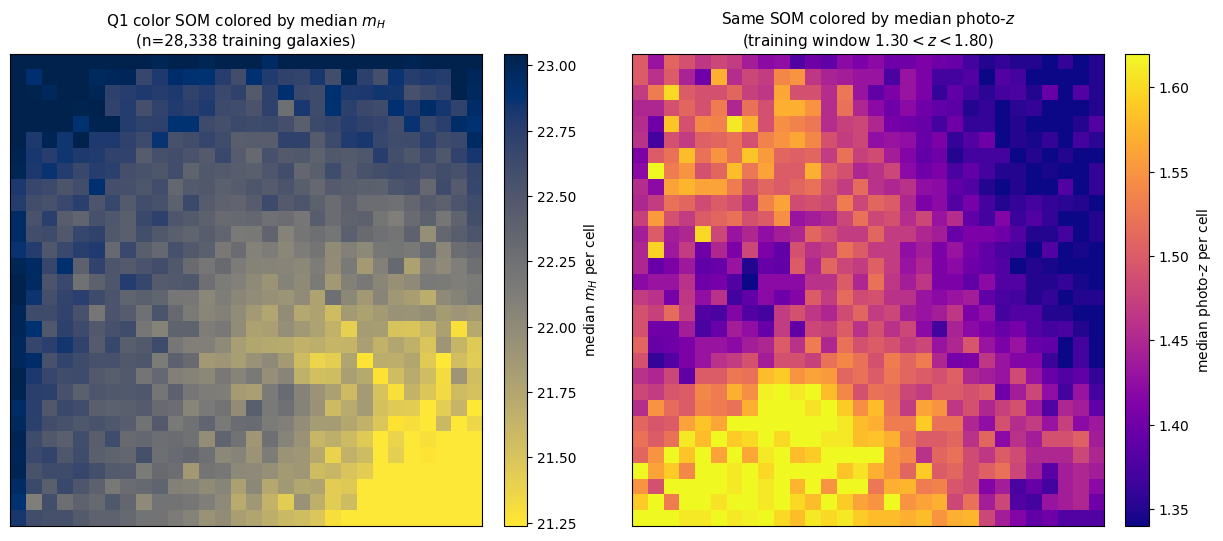

In [32]:
# Color the SOM by two per-cell aggregates of the training galaxies:
#   left  - median observed-frame H-band magnitude (host brightness proxy)
#   right - median photometric redshift (within the training window)
med_mH = median_map(train['mH_obs'], bmu_train, msz=MSZ)
mH_bg = fill_nan_nearest(med_mH)
mH_lo, mH_hi = np.nanpercentile(med_mH, [5, 95])

med_z = median_map(train['phz_median'], bmu_train, msz=MSZ)
z_bg = fill_nan_nearest(med_z)
z_lo, z_hi = np.nanpercentile(med_z, [5, 95])

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.4))
im0 = axes[0].imshow(mH_bg, origin='lower', cmap='cividis_r', vmin=mH_lo, vmax=mH_hi)
axes[0].set_xticks([]); axes[0].set_yticks([])
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04).set_label('median $m_H$ per cell', fontsize=10)
axes[0].set_title(f'Q1 color SOM colored by median $m_H$\n(n={len(train):,} training galaxies)', fontsize=11)

im1 = axes[1].imshow(z_bg, origin='lower', cmap='plasma', vmin=z_lo, vmax=z_hi)
axes[1].set_xticks([]); axes[1].set_yticks([])
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04).set_label('median photo-$z$ per cell', fontsize=10)
axes[1].set_title(f'Same SOM colored by median photo-$z$\n(training window $1.30 < z < 1.80$)', fontsize=11)

plt.tight_layout(); plt.show()


## Task 1 - Query AGNs live and project them onto the SOM (~10 min)

The shipped `workshop_agn_flags_edfn.fits` carries only object IDs, sky positions,
redshifts, and the binary AGN selection flags - **no photometry**. To project these
sources onto the SOM you need their six adjacent colors, which means fetching the
seven-band MER fluxes (`g, r, i, z, Y, J, H`) live from IRSA's TAP service.

The cell below does exactly that: a batched TAP query against
`euclid_q1_mer_catalogue` for the ~5k AGN object IDs. On a workshop wifi this
takes roughly 30-90 seconds (five batches of ~1000 IDs each). If the network
blocks or IRSA's TAP endpoint is slow, the cell falls back to a pre-projected
file shipped with the notebook so the rest of the workshop still works.


In [33]:
# Live MER photometry query (with fallback to a pre-projected cache).
FALLBACK_PATH = os.path.join(CACHE_DIR, 'workshop_agn_edfn.fits')

FLUX_COLS = [
    'flux_g_ext_hsc_templfit',       'fluxerr_g_ext_hsc_templfit',
    'flux_r_ext_megacam_templfit',   'fluxerr_r_ext_megacam_templfit',
    'flux_i_ext_panstarrs_templfit', 'fluxerr_i_ext_panstarrs_templfit',
    'flux_z_ext_hsc_templfit',       'fluxerr_z_ext_hsc_templfit',
    'flux_y_templfit',               'fluxerr_y_templfit',
    'flux_j_templfit',               'fluxerr_j_templfit',
    'flux_h_templfit',               'fluxerr_h_templfit',
]
ids = np.unique(np.asarray(flags['object_id_euclid'], dtype=np.int64))
print(f'Asking IRSA for MER photometry of {len(ids):,} EDF-N AGN candidates...')

used_fallback = False
try:
    phot = batched_query('euclid_q1_mer_catalogue', FLUX_COLS, ids,
                         id_col='object_id', desc='MER phot')
    if 'object_id' in phot.colnames:
        phot.rename_column('object_id', 'object_id_euclid')
    agn = join(flags, phot, keys='object_id_euclid', join_type='inner')
    print(f'Live TAP returned photometry for {len(phot):,} / {len(ids):,} sources.')
except Exception as exc:
    print(f'\nLive TAP query failed: {exc!r}')
    print(f'Falling back to {FALLBACK_PATH} (pre-projected).')
    agn = Table.read(FALLBACK_PATH)
    used_fallback = True

print(f'AGN table now has {len(agn):,} rows, {len(agn.colnames)} columns.')


Asking IRSA for MER photometry of 4,786 EDF-N AGN candidates...


MER phot: 100%|██████████| 5/5 [00:49<00:00,  9.98s/batch]

Live TAP returned photometry for 4,786 / 4,786 sources.
AGN table now has 4,786 rows, 37 columns.


After 7-band S/N > 5 and AB in [12, 30] gates: 4,786 AGN.
Projected onto SOM: 4,786; inliers (QE <= 2.35): 3,517.


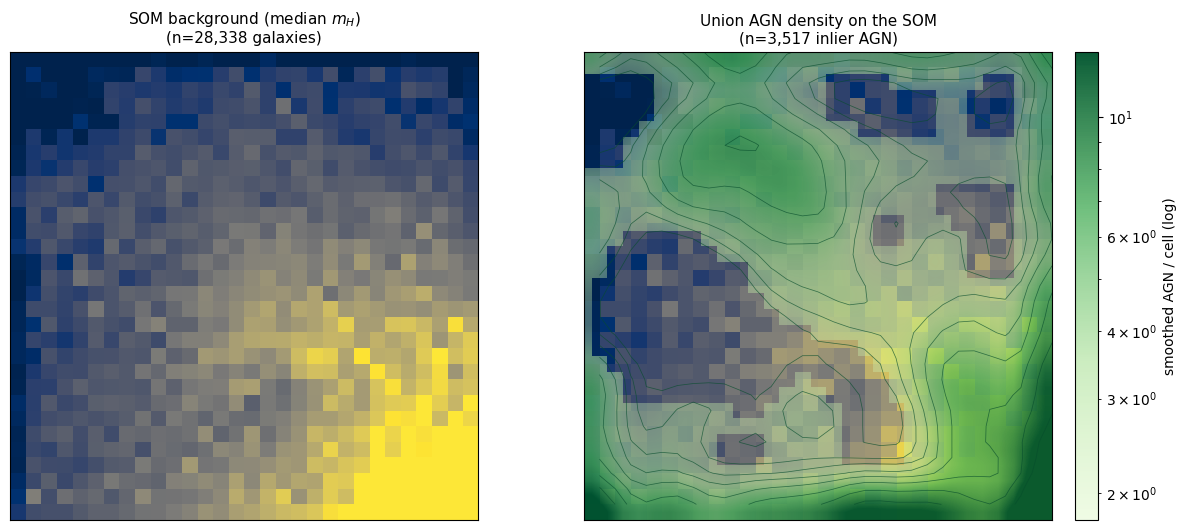

In [34]:
# Compute six adjacent colors from the MER north-system fluxes, apply
# photometric gates, then project onto the SOM and plot the union density.
SNR_MIN = 5.0
MAG_MIN, MAG_MAX = 12, 30

gf  = np.asarray(agn['flux_g_ext_hsc_templfit'],        float)
ge  = np.asarray(agn['fluxerr_g_ext_hsc_templfit'],     float)
rf  = np.asarray(agn['flux_r_ext_megacam_templfit'],    float)
re_ = np.asarray(agn['fluxerr_r_ext_megacam_templfit'], float)
if_ = np.asarray(agn['flux_i_ext_panstarrs_templfit'],  float)
ie  = np.asarray(agn['fluxerr_i_ext_panstarrs_templfit'], float)
zf  = np.asarray(agn['flux_z_ext_hsc_templfit'],        float)
ze  = np.asarray(agn['fluxerr_z_ext_hsc_templfit'],     float)
yf  = np.asarray(agn['flux_y_templfit'], float); ye = np.asarray(agn['fluxerr_y_templfit'], float)
jf  = np.asarray(agn['flux_j_templfit'], float); je = np.asarray(agn['fluxerr_j_templfit'], float)
hf  = np.asarray(agn['flux_h_templfit'], float); he = np.asarray(agn['fluxerr_h_templfit'], float)

g, r, i, z = abmag(gf), abmag(rf), abmag(if_), abmag(zf)
y, j, h    = abmag(yf), abmag(jf), abmag(hf)
agn['gr'], agn['ri'], agn['iz'] = g - r, r - i, i - z
agn['zy'], agn['yj'], agn['jh'] = z - y, y - j, j - h
agn['mH_obs'] = h

snr_ok = (
    (snr(gf, ge) > SNR_MIN) & (snr(rf, re_) > SNR_MIN) & (snr(if_, ie) > SNR_MIN) &
    (snr(zf, ze) > SNR_MIN) & (snr(yf, ye) > SNR_MIN) & (snr(jf, je) > SNR_MIN) &
    (snr(hf, he) > SNR_MIN)
)
mag_ok = (valid_mag(g) & valid_mag(r) & valid_mag(i) & valid_mag(z) &
          valid_mag(y) & valid_mag(j) & valid_mag(h))
agn = agn[snr_ok & mag_ok]
print(f'After 7-band S/N > {SNR_MIN:.0f} and AB in [{MAG_MIN}, {MAG_MAX}] gates: {len(agn):,} AGN.')

# Project onto the SOM (returns BMU and quantization error per source).
ok, bmu, qe = project(agn, som, mu, sigma)
agn = agn[ok].copy()
agn['bmu_row'] = bmu[:, 0]
agn['bmu_col'] = bmu[:, 1]
agn['qe'] = qe
agn['qe_inlier'] = qe <= qe_thresh
agn_in = agn[agn['qe_inlier']]
bmu_in = np.column_stack([agn_in['bmu_row'], agn_in['bmu_col']]).astype(int)
print(f'Projected onto SOM: {len(agn):,}; inliers (QE <= {qe_thresh:.2f}): {len(agn_in):,}.')

# Plot the SOM background with the union AGN density overlaid.
H_union = bmu_density(bmu_in)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.4))
for ax in axes:
    ax.imshow(mH_bg, origin='lower', cmap='cividis_r', vmin=mH_lo, vmax=mH_hi)
    ax.set_xticks([]); ax.set_yticks([])
axes[0].set_title(f'SOM background (median $m_H$)\n(n={len(train):,} galaxies)', fontsize=11)
im_d, _, _ = overlay(axes[1], H_union)
if im_d is not None:
    fig.colorbar(im_d, ax=axes[1], fraction=0.046, pad=0.04).set_label('smoothed AGN / cell (log)', fontsize=10)
axes[1].set_title(f'Union AGN density on the SOM\n(n={len(agn_in):,} inlier AGN)', fontsize=11)
plt.tight_layout(); plt.show()


## Task 2 - Where does *your* selection method live? (~10 min)

The union map you just produced mixes every AGN selection technique into one
footprint. Different methods sample different physics: WISE colors trace hot
dust, Euclid NIR colors trace mid-IR-like features in extended bandpasses,
Gaia DR3 selects bright quasars by parallax/photometry, etc. On a common
manifold we can ask: *do these methods land in the same place, or different
ones?*

Available flags in this EDF-N sample (each is a 0/1 column on `agn_in`):

| Flag column | What it selects |
| --- | --- |
| `R90_agn_candidate` | WISE mid-IR color, 90% reliability (Assef+18) |
| `C75_agn_candidate` | WISE mid-IR color, 75% completeness (Assef+18) |
| `JH_IeY_qso_candidate` | Euclid NIR two-color box (Bisigello+24) |
| `IeH_gz_qso_candidate` | Euclid + optical color box (Bisigello+24) |
| `B24a_qso_candidate` | Optical + NIR color cut (Bisigello+24 a) |
| `B24b_qso_candidate` | Optical + NIR color cut (Bisigello+24 b) |
| `GDR3_qso_candidate` | Gaia DR3 quasar candidate |
| `PRF_qso_candidate` | Probabilistic Random Forest |
| `AGN_sed_candidate` | SED-template based (EDF-N only) |
| `DESI_broadline_qso_candidate` | DESI spec-confirmed broad-line QSO |
| `DESI_niibpt_agn_candidate` | DESI [NII]/H$\alpha$ BPT AGN |

**Your task:** pick *one* flag in the cell below. The cell will plot two panels:
left = where that method's AGN sit on the SOM; right = where they are *enriched*
relative to the union AGN distribution (green = preferred regions for that method).

Compare with your neighbor: did you pick the same place on the manifold?


AGN flagged by R90_agn_candidate: 123 (out of 3,517 inliers)


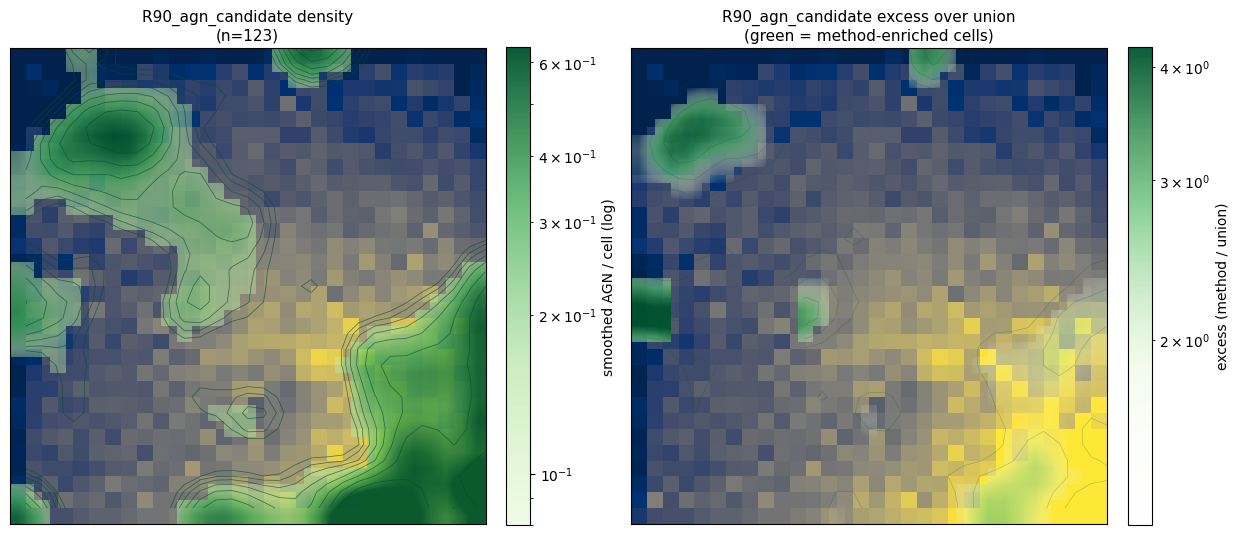

In [35]:
# === TODO: pick one flag column from the table above =====================
method = 'R90_agn_candidate'      # <-- change this to any flag column name
# ==========================================================================

assert method in agn_in.colnames, f'{method!r} is not a column in agn_in.'
method_mask = np.asarray(agn_in[method] == 1)
n_method = int(method_mask.sum())
print(f'AGN flagged by {method}: {n_method:,} (out of {len(agn_in):,} inliers)')

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.4))
for ax in axes:
    ax.imshow(mH_bg, origin='lower', cmap='cividis_r', vmin=mH_lo, vmax=mH_hi)
    ax.set_xticks([]); ax.set_yticks([])

# Left: BMUs and smoothed density of the selected method.
H_method = bmu_density(bmu_in[method_mask]) if n_method else None
if H_method is not None:
    im_d, _, _ = overlay(axes[0], H_method)
    if im_d is not None:
        fig.colorbar(im_d, ax=axes[0], fraction=0.046, pad=0.04).set_label('smoothed AGN / cell (log)', fontsize=10)
if 0 < n_method <= 60:
    x_pt, y_pt = jitter_bmu(bmu_in[method_mask], seed=42)
    axes[0].scatter(x_pt, y_pt, marker='x', s=30, linewidths=0.9,
                    color='white', alpha=0.9, zorder=5)
    axes[0].scatter(x_pt, y_pt, marker='x', s=30, linewidths=0.55,
                    color=AGN_OVERLAY_COLOR, alpha=0.9, zorder=6)
axes[0].set_title(f'{method} density\n(n={n_method:,})', fontsize=11)

# Right: method-excess over the union distribution.
im_x = overlay_method_excess(axes[1], H_method, H_union)
if im_x is not None:
    fig.colorbar(im_x, ax=axes[1], fraction=0.046, pad=0.04).set_label('excess (method / union)', fontsize=10)
axes[1].set_title(f'{method} excess over union\n(green = method-enriched cells)', fontsize=11)
plt.tight_layout(); plt.show()


**Discussion prompt.** Where on the SOM did your method land? Bright-host cells (light)
or faint-host cells (dark)? Is the enrichment spread out across the manifold or
concentrated in one corner? Compare with someone who picked a different flag - the
*excess* maps usually disagree, even when the *density* maps look similar.


## Task 3 - Pick one candidate and verify it with three live cloud reads (~10 min)

Draw a random AGN from the spec-z inliers Task 1 just produced (so the predicted
observed-frame H$\alpha$ wavelength `λ_obs = 6562.8 × (1+z)` is accurate to a few
Angstroms), project it onto the SOM (a repeat of the Task 1 calculation for a
single source — same answer, different code path so you can see how `winner()`
works on one input), then pull three independent measurements **live from IRSA**
to check whether the colors-and-manifold prediction agrees with the actual
photons:

- **3b** SIR 1D spectrum - direct S3 FITS read from `s3://nasa-irsa-euclid-q1/...`
- **3c** MER multi-band imaging - server-side cutout from IRSA IBE
- **3d** SPE H$\alpha$ line measurement - one-row TAP query against the SPE line catalog

Different people in the room will draw different sources — compare with your
neighbor at the end.


In [36]:
# === TODO: pick a candidate ===============================================
# Random draw from spec-z inliers produced in Task 1. SIR coverage in EDF-N
# is essentially 100% for inlier AGN, so the cells below almost always work;
# the missing-spectrum branch in 3b handles the rare exception gracefully.
specz = agn_in[agn_in['z_source'] == 'spec']
print(f'Spec-z inliers available: {len(specz):,}')

# Change the seed (or set seed=None) to draw a different AGN.
rng = np.random.default_rng(seed=42)
row = specz[int(rng.integers(len(specz)))]
# ==========================================================================

my_id = int(row['object_id_euclid'])
ra, dec = float(row['ra_euclid']), float(row['dec_euclid'])
z = float(row['z_final'])
print(f'Chose object_id {my_id}')
print(f'  RA, Dec = {ra:.6f}, {dec:.6f}')
print(f'  z = {z:.3f} ({row["z_source"]})')
print(f'  Task-1 BMU: ({int(row["bmu_row"])}, {int(row["bmu_col"])})')


Spec-z inliers available: 763
Chose object_id 2668535469662563116
  RA, Dec = 266.853547, 66.256312
  z = 1.606 (spec)
  Task-1 BMU: (24, 9)


### 3a. Project the candidate onto the SOM (local compute)

To project a source onto the SOM you need its six adjacent colors normalized the
same way as the training sample (z-score with the training `mu`, `sigma`), then
the SOM's `winner()` method returns the best-matching unit (BMU). This step is
pure local arithmetic - no cloud reads. The BMU should match the value Task 1
attached to this row.


Colors: {'gr': np.float64(0.153), 'ri': np.float64(0.001), 'iz': np.float64(0.047), 'zy': np.float64(0.118), 'yj': np.float64(0.144), 'jh': np.float64(0.257)}
Projected BMU: (np.int64(24), np.int64(9))  (Task 1 attached (24, 9))


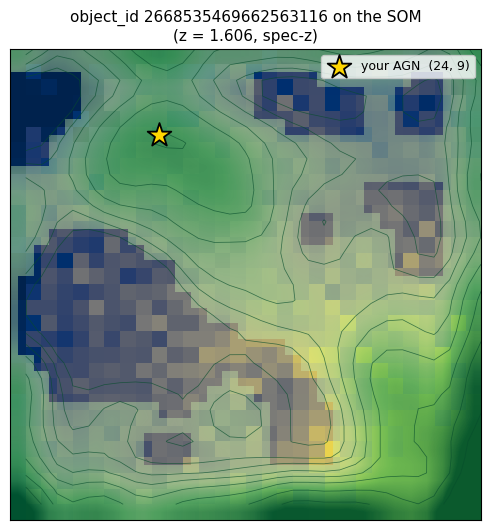

In [37]:
# === TODO: normalize the candidate's colors and find its BMU =============
colors = np.array([row[c] for c in COLOR_NAMES])   # six adjacent colors (mag)
print('Colors:', dict(zip(COLOR_NAMES, np.round(colors, 3))))

v_norm = (colors - mu) / sigma                      # z-score with training stats
bmu = som.winner(v_norm)                            # (row, col) on the SOM grid
# ==========================================================================
print(f'Projected BMU: {bmu}  (Task 1 attached ({int(row["bmu_row"])}, {int(row["bmu_col"])}))')

# Plot the BMU on top of the union AGN density background.
fig, ax = plt.subplots(figsize=(6.4, 5.4))
ax.imshow(mH_bg, origin='lower', cmap='cividis_r', vmin=mH_lo, vmax=mH_hi)
if H_union is not None:
    overlay(ax, H_union)
ax.scatter(bmu[1], bmu[0], marker='*', s=320, edgecolors='black', linewidths=1.3,
           facecolor='gold', zorder=10, label=f'your AGN  ({bmu[0]}, {bmu[1]})')
ax.set_xticks([]); ax.set_yticks([])
ax.legend(loc='upper right', frameon=True, fontsize=9)
ax.set_title(f'object_id {my_id} on the SOM\n(z = {z:.3f}, {row["z_source"]}-z)', fontsize=11)
plt.tight_layout(); plt.show()


### 3b. Pull the SIR spectrum live from S3

Two cloud calls happen here. First, a TAP query against IRSA's spectrum-association
table to find which FITS file in the public bucket contains this object's spectrum
(a sub-second SQL lookup). Second, an `astropy.io.fits.open(s3_uri, ...)` against
`s3://nasa-irsa-euclid-q1/...` with `fsspec` - that's a **direct anonymous S3 read**
of the FITS file, no download.


In [38]:
# Step 1: TAP query for the spectrum-file association.
adql_assoc = (
    'SELECT objectid, path, hdu '
    f'FROM {SPECTRA_ASSOC_TABLE} '
    f'WHERE objectid = {my_id}'
)
print('TAP query:')
print(adql_assoc)
assoc = Irsa.query_tap(adql_assoc).to_table()
print(f'Returned {len(assoc)} row(s).')

have_spectrum = len(assoc) > 0
if not have_spectrum:
    print('  -- no Q1 SIR spectrum recorded for this object_id.')
    print('     Imaging (3c) still works; pick a different object_id if you')
    print('     want to see a spectrum here.')
else:
    for r in assoc:
        print(f'  hdu={int(r["hdu"]):>3d}  path={r["path"]}')
    # Step 2: build the S3 URI for the spectrum FITS and open it directly.
    from workshop_utils import association_to_s3_uri
    first = assoc[0]
    s3_uri = association_to_s3_uri(first['path'])
    print(f'\nReading from: {s3_uri}')
    print(f'  HDU index in that file: {int(first["hdu"])}')


TAP query:
SELECT objectid, path, hdu FROM euclid.objectid_spectrafile_association_q1 WHERE objectid = 2668535469662563116
Returned 1 row(s).
  hdu=1409  path=api/spectrumdm/convert/euclid/q1/SIR/102159484/EUC_SIR_W-COMBSPEC_102159484_2024-11-05T15:55:24.589653Z.fits?dataset_id=euclid_combspec&hdu=1409

Reading from: s3://nasa-irsa-euclid-q1/q1/SIR/102159484/EUC_SIR_W-COMBSPEC_102159484_2024-11-05T15:55:24.589653Z.fits
  HDU index in that file: 1409


Opening spectrum FITS files: 100%|██████████| 1/1 [00:10<00:00, 10.50s/file]

wavelength samples: 468
observed range:     12490 Angstrom - 18747 Angstrom


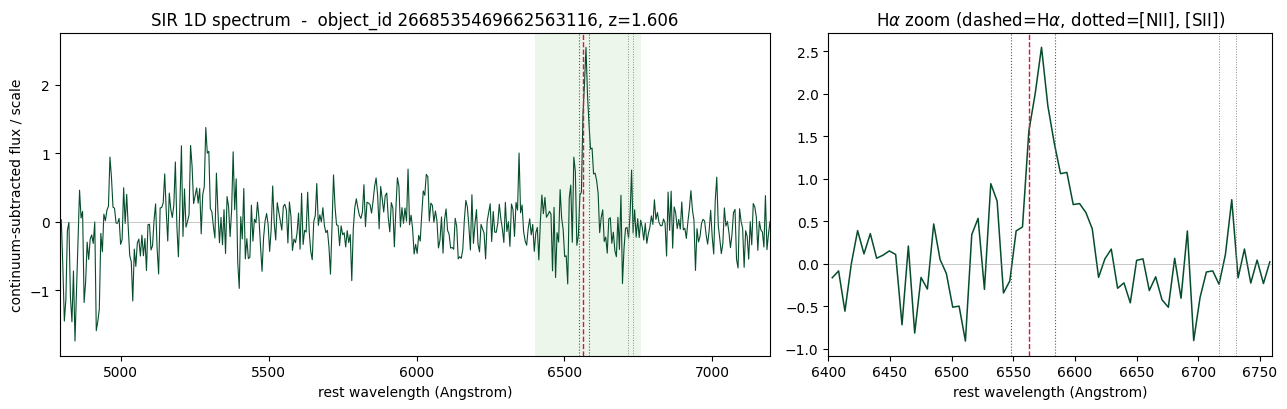

In [39]:
# Skip cleanly if the source has no SIR association; otherwise read the FITS
# from S3 and plot. The helper does the same fits.open(s3_uri, fsspec_kwargs=...)
# under the hood, with a local .npz cache for repeat calls on the same id.
if not have_spectrum:
    print('No SIR spectrum to read. Move on to cell 3c (imaging).')
else:
    one_row = agn[agn['object_id_euclid'] == my_id]
    spectra = get_Q1_sir_spectra(one_row, n=1, cache_check=True)
    if my_id not in spectra:
        print('Association returned a row but the FITS HDU was unreadable. Skipping.')
    else:
        spec = spectra[my_id]
        print(f'wavelength samples: {len(spec["wave"]):,}')
        print(f'observed range:     {spec["wave"][0]:.0f} - {spec["wave"][-1]:.0f}')

        rest, y = continuum_normalized_rest_spectrum(spec, z)
        fig, (axw, axz) = plt.subplots(1, 2, figsize=(13.0, 4.2),
                                        gridspec_kw={'width_ratios': [1.6, 1.0]})
        axw.plot(rest, y, color='#064d2c', lw=0.8)
        axw.axhline(0, color='0.5', lw=0.6, alpha=0.5)
        axw.axvspan(6400, 6760, color='#82c77a', alpha=0.15, lw=0)
        mark_halpha_complex(axw, full_range=True)
        axw.set_xlim(np.nanmin(rest), np.nanmax(rest))
        axw.set_xlabel('rest wavelength (Angstrom)')
        axw.set_ylabel('continuum-subtracted flux / scale')
        axw.set_title(f'SIR 1D spectrum  -  object_id {my_id}, z={z:.3f}')
        zoom = (rest > 6400) & (rest < 6760)
        axz.plot(rest[zoom], y[zoom], color='#064d2c', lw=1.1)
        axz.axhline(0, color='0.5', lw=0.6, alpha=0.5)
        mark_halpha_complex(axz, full_range=True)
        axz.set_xlim(6400, 6760)
        axz.set_xlabel('rest wavelength (Angstrom)')
        axz.set_title(r'H$\alpha$ zoom (dashed=H$\alpha$, dotted=[NII], [SII])')
        plt.tight_layout(); plt.show()


### 3c. Pull multi-band MER imaging cutouts live from IRSA IBE

Now an imaging look at the same source. We use IRSA's IBE cutout service:
an SIA query returns the URL of the full MER mosaic FITS that covers our position;
we append `?center=ra,dec&size=Xarcsec` to ask the server to return only the
small region we want. The server-side cutout comes back as a ~40 KB gzipped FITS
in a fraction of a second - no need to stream the full 1.4 GB mosaic.

Below we fetch VIS (high-resolution optical) and three NISP NIR bands (Y, J, H).


In [40]:
# Fetch four bands - the helper prints each cutout URL so you can see the cloud calls.
from workshop_utils import _mer_sia_lookup
import time

t0 = time.time()
sia_rows = _mer_sia_lookup(ra, dec)
print(f'SIA query: {time.time()-t0:.2f} s, {len(sia_rows)} mosaic rows at this position')
print('IBE cutout URLs being fetched:')

BANDS = ['VIS', 'Y', 'J', 'H']
cutouts = {}
t0 = time.time()
for b in BANDS:
    cutouts[b] = get_Q1_mer_cutout(ra, dec, band=b, size_arcsec=8.0, sia_rows=sia_rows, verbose=True)
print(f'Fetched {len(BANDS)} cutouts in {time.time()-t0:.2f} s')

# Print one S3 URI to make the cloud location explicit.
print(f'\n(For reference, the underlying S3 path of the VIS mosaic was:')
print(f' {cutouts["VIS"]["s3_uri"]})')


SIA query: 0.90 s, 98 mosaic rows at this position
IBE cutout URLs being fetched:
  band VIS: https://irsa.ipac.caltech.edu/ibe/data/euclid/q1/MER/102159484/VIS/EUC_MER_BGSUB-MOSAIC-VIS_TILE102159484-116033_20241025T015934.885975Z_00.00.fits?center=266.853547,66.256312&size=8.00arcsec
  band Y: https://irsa.ipac.caltech.edu/ibe/data/euclid/q1/MER/102159484/NISP/EUC_MER_BGSUB-MOSAIC-NIR-Y_TILE102159484-A9CCA7_20241024T221227.957725Z_00.00.fits?center=266.853547,66.256312&size=8.00arcsec
  band J: https://irsa.ipac.caltech.edu/ibe/data/euclid/q1/MER/102159484/NISP/EUC_MER_BGSUB-MOSAIC-NIR-J_TILE102159484-C026DB_20241024T213141.416722Z_00.00.fits?center=266.853547,66.256312&size=8.00arcsec
  band H: https://irsa.ipac.caltech.edu/ibe/data/euclid/q1/MER/102159484/NISP/EUC_MER_BGSUB-MOSAIC-NIR-H_TILE102159484-39CF67_20241024T214009.099906Z_00.00.fits?center=266.853547,66.256312&size=8.00arcsec
Fetched 4 cutouts in 1.02 s

(For reference, the underlying S3 path of the VIS mosaic was:
 s3://na

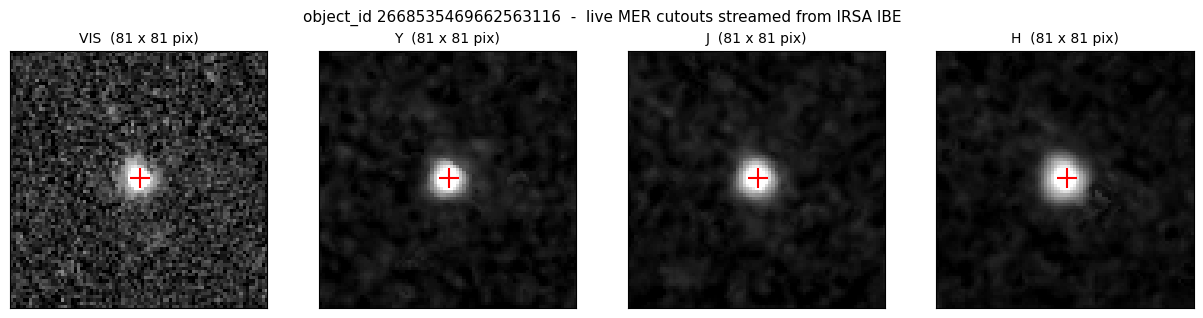

In [41]:
# Display the four bands side-by-side with consistent arcsinh stretch per panel.
from matplotlib.colors import AsinhNorm

fig, axes = plt.subplots(1, len(BANDS), figsize=(3.0 * len(BANDS) + 0.5, 3.2))
for ax, b in zip(axes, BANDS):
    data = cutouts[b]['data']
    vmin = float(np.nanpercentile(data, 5))
    vmax = float(np.nanpercentile(data, 99.5))
    span = max(vmax - vmin, 1e-6)
    ax.imshow(data, origin='lower', cmap='gray',
              norm=AsinhNorm(linear_width=0.1 * span, vmin=vmin, vmax=vmax))
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'{b}  ({data.shape[1]} x {data.shape[0]} pix)', fontsize=10)
    # Center crosshair on source position.
    yc, xc = data.shape[0] / 2, data.shape[1] / 2
    ax.plot(xc, yc, marker='+', color='red', markersize=14, markeredgewidth=1.5)
fig.suptitle(f'object_id {my_id}  -  live MER cutouts streamed from IRSA IBE', fontsize=11)
plt.tight_layout(); plt.show()


### 3d. Look up the catalog SPE H$\alpha$ measurement (live TAP)

Finally a quick cross-check against Euclid's own automated line-feature catalog.
SPE measures Gaussian fits to spectral lines and stores flux, EW, and S/N per line.
We run a one-row ADQL query for this object's H$\alpha$ row(s) and compare with
what we just saw in the 1D spectrum.


In [42]:
# === Live TAP query - the SPE line-feature catalog is not pre-cached =====
adql_spe = (
    'SELECT spe_rank, spe_line_central_wl_gf, spe_line_flux_gf, '
    'spe_line_flux_err_gf, spe_line_snr_gf, spe_line_ew_gf '
    f'FROM {SPE_LINES_TABLE} '
    f'WHERE object_id = {my_id} '
    "AND spe_line_name = 'Halpha'"
)
print('Live TAP query:')
print(adql_spe)

result = Irsa.query_tap(adql_spe).to_table()
print(f'\nReturned {len(result)} row(s):')
if len(result) == 0:
    print('  (no Halpha measurement in the SPE catalog for this source.)')
else:
    result.pprint(max_lines=10, max_width=120)
    print()
    best = result[np.argmax(np.asarray(result['spe_line_snr_gf'], dtype=float))]
    print(f'Best-S/N row:  central wavelength = {float(best["spe_line_central_wl_gf"]):.1f} Angstrom (observed)')
    print(f'               flux  = {float(best["spe_line_flux_gf"]):.3e} erg/s/cm2')
    print(f'               S/N   = {float(best["spe_line_snr_gf"]):.2f}')
    print(f'               |EW|  = {abs(float(best["spe_line_ew_gf"])):.1f} Angstrom')
    print(f'Predicted Halpha at z={z:.3f}: observed wavelength = '
          f'{6562.8 * (1+z):.1f} Angstrom (rest 6562.8 A)')


Live TAP query:
SELECT spe_rank, spe_line_central_wl_gf, spe_line_flux_gf, spe_line_flux_err_gf, spe_line_snr_gf, spe_line_ew_gf FROM euclid_q1_spe_lines_line_features WHERE object_id = 2668535469662563116 AND spe_line_name = 'Halpha'

Returned 5 row(s):
spe_rank spe_line_central_wl_gf spe_line_flux_gf spe_line_flux_err_gf spe_line_snr_gf spe_line_ew_gf
-------- ---------------------- ---------------- -------------------- --------------- --------------
       0            17109.14648  3.617006444e-16      6.419245808e-17     13.60371685   -460.2634277
       1                    -99              -99                  -99             -99            -99
       2                    -99              -99                  -99             -99            -99
       3                    -99              -99                  -99             -99            -99
       4                    -99              -99                  -99             -99            -99

Best-S/N row:  central wavelength = 1

**Three independent cloud reads, one consistent answer.** The 1D spectrum shows the
line, the imaging shows the host, and the SPE catalog quantifies the line - all
fetched live from `irsa.ipac.caltech.edu` or `nasa-irsa-euclid-q1` in this notebook,
with no preloaded data products beyond the SOM weights and the AGN flag table.

Try changing `my_id` to one of the other curated picks, or to any `object_id_euclid`
from `agn_in`, and rerunning Task 3. Different SOM neighborhoods often correspond to
different AGN flavors - compact point source vs extended host, broad-line vs narrow,
bright vs faint - which you can read off directly from the imaging cell.


## Wrap-up

In ~30 minutes you have:

1. Loaded a pre-trained Q1 color SOM and a small flag-only EDF-N AGN table.
2. **Live-queried IRSA's TAP service** for the seven-band MER photometry of those AGN, computed six adjacent colors, applied the same photometric gates as the full pipeline, and projected every candidate onto the SOM.
3. Picked one AGN selection method and visualized where it is enriched on the manifold relative to the union.
4. Drew a random spec-z AGN from the inlier set and verified it with **three independent live cloud reads**:
   - a 1D SIR spectrum read directly from `s3://nasa-irsa-euclid-q1/...`,
   - multi-band MER imaging cutouts streamed from IRSA's IBE server-side cutout service,
   - a one-row SPE H$\alpha$ measurement from a live TAP query.

**The cloud point.** The only data shipped with this notebook is a 70 KB SOM
pickle and a 350 KB flag-only AGN table — everything else is fetched live. The
same code, run from a Fornax JupyterLab session in the same AWS region, would
complete in a fraction of the time you saw here (the SIA + IBE round-trips dominate
from a laptop). It scales unchanged to the full Q1 release (~30M sources, ~150 deg2)
and onward to DR1 with no rewrite.

**Where to go next.**

- Full pipeline (queries, training, all 3 fields, north/south overlays, SPE H$\alpha$
  diagnostics): `Euclid_AGN_Tutorial.ipynb` (in the project root).
- IRSA's reference Euclid Q1 cloud-access tutorial:
  https://caltech-ipac.github.io/irsa-tutorials/euclid-cloud-access/
- Cluster-finding example: [IRSA Euclid clusters tutorial](https://caltech-ipac.github.io/irsa-tutorials/euclid-clusters-tutorial/).
- SPE line-feature catalog: [IRSA Euclid SPE catalog tutorial](https://caltech-ipac.github.io/irsa-tutorials/euclid-intro-spe-catalog/).

**Acknowledgments.** AGN candidate catalogs from Euclid Collaboration: Matamoro Zatarain
et al. (2025); Q1 data products distributed by NASA/IPAC IRSA. The SOM methodology
extends Sanjaripour et al. (2024) and a companion Euclid Q1 paper (in prep).
